# TPC-C Multi-Tenant with Distributed PVC and Tuned PostgreSQL 17.5

* data is generated and loaded into databases in a distributed filesystem
* experiments do not use preloaded data

* PostgreSQL uses improved args:
```
# --- Connection & Worker Processes ---
- "-c"
- "max_connections=1500"       # https://www.postgresql.org/docs/current/runtime-config-connection.html#GUC-MAX-CONNECTIONS
- "-c"
- "max_worker_processes=128"   # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-MAX-WORKER-PROCESSES
- "-c"
- "max_parallel_workers=64"    # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-MAX-PARALLEL-WORKERS
- "-c"
- "max_parallel_workers_per_gather=8"  # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-MAX-PARALLEL-WORKERS-PER-GATHER
- "-c"
- "max_parallel_maintenance_workers=8" # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-MAX-PARALLEL-MAINTENANCE-WORKERS

# --- Memory Settings ---
- "-c"
- "shared_buffers=256GB"       # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-SHARED-BUFFERS
- "-c"
- "effective_cache_size=350GB" # https://www.postgresql.org/docs/current/runtime-config-query.html#GUC-EFFECTIVE-CACHE-SIZE
- "-c"
- "work_mem=128MB"             # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-WORK-MEM
- "-c"
- "maintenance_work_mem=4GB"   # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-MAINTENANCE-WORK-MEM
- "-c"
- "temp_buffers=64MB"          # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-TEMP-BUFFERS
- "-c"
- "wal_buffers=16MB"           # https://www.postgresql.org/docs/current/runtime-config-wal.html#GUC-WAL-BUFFERS
- "-c"
- "autovacuum_work_mem=1GB"    # https://www.postgresql.org/docs/current/runtime-config-autovacuum.html#GUC-AUTOVACUUM-WORK-MEM

# --- Autovacuum ---
- "-c"
- "autovacuum=on"                            # https://www.postgresql.org/docs/current/runtime-config-autovacuum.html#GUC-AUTOVACUUM
- "-c"
- "autovacuum_max_workers=10"               # https://www.postgresql.org/docs/current/runtime-config-autovacuum.html#GUC-AUTOVACUUM-MAX-WORKERS
- "-c"
- "autovacuum_vacuum_cost_limit=1000"       # https://www.postgresql.org/docs/current/runtime-config-autovacuum.html#GUC-AUTOVACUUM-VACUUM-COST-LIMIT
- "-c"
- "vacuum_cost_limit=1000"                  # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-VACUUM-COST-LIMIT
- "-c"
- "autovacuum_naptime=15s"                  # https://www.postgresql.org/docs/current/runtime-config-autovacuum.html#GUC-AUTOVACUUM-NAPTIME
- "-c"
- "autovacuum_vacuum_cost_delay=20ms"       # https://www.postgresql.org/docs/current/runtime-config-autovacuum.html#GUC-AUTOVACUUM-VACUUM-COST-DELAY

# --- WAL & Checkpoints (Ceph-optimized) ---
- "-c"
- "wal_level=replica"                       # https://www.postgresql.org/docs/current/runtime-config-wal.html#GUC-WAL-LEVEL
- "-c"
- "wal_compression=on"                      # https://www.postgresql.org/docs/current/runtime-config-wal.html#GUC-WAL-COMPRESSION
- "-c"
- "wal_writer_delay=500ms"                  # https://www.postgresql.org/docs/current/runtime-config-wal.html#GUC-WAL-WRITER-DELAY
- "-c"
- "commit_delay=10000"                      # https://www.postgresql.org/docs/current/runtime-config-wal.html#GUC-COMMIT-DELAY
- "-c"
- "synchronous_commit=off"                  # https://www.postgresql.org/docs/current/runtime-config-wal.html#GUC-SYNCHRONOUS-COMMIT
- "-c"
- "max_wal_size=2GB"                        # https://www.postgresql.org/docs/current/runtime-config-wal.html#GUC-MAX-WAL-SIZE
- "-c"
- "min_wal_size=1GB"                        # https://www.postgresql.org/docs/current/runtime-config-wal.html#GUC-MIN-WAL-SIZE
- "-c"
- "checkpoint_timeout=15min"                # https://www.postgresql.org/docs/current/runtime-config-wal.html#GUC-CHECKPOINT-TIMEOUT
- "-c"
- "checkpoint_completion_target=0.9"        # https://www.postgresql.org/docs/current/runtime-config-wal.html#GUC-CHECKPOINT-COMPLETION-TARGET

# --- Planner Cost Tweaks (CephFS) ---
- "-c"
- "random_page_cost=4.0"                    # https://www.postgresql.org/docs/current/runtime-config-query.html#GUC-RANDOM-PAGE-COST
- "-c"
- "seq_page_cost=1.5"                       # https://www.postgresql.org/docs/current/runtime-config-query.html#GUC-SEQ-PAGE-COST
- "-c"
- "cpu_tuple_cost=0.01"                     # https://www.postgresql.org/docs/current/runtime-config-query.html#GUC-CPU-TUPLE-COST
- "-c"
- "effective_io_concurrency=2"              # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-EFFECTIVE-IO-CONCURRENCY
- "-c"
- "default_statistics_target=500"           # https://www.postgresql.org/docs/current/runtime-config-query.html#GUC-DEFAULT-STATISTICS-TARGET

# --- Locks and Limits ---
- "-c"
- "max_locks_per_transaction=128"           # https://www.postgresql.org/docs/current/runtime-config-locks.html#GUC-MAX-LOCKS-PER-TRANSACTION
- "-c"
- "max_pred_locks_per_transaction=128"      # https://www.postgresql.org/docs/current/runtime-config-locks.html#GUC-MAX-PRED-LOCKS-PER-TRANSACTION
- "-c"
- "max_stack_depth=7MB"                     # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-MAX-STACK-DEPTH
- "-c"
- "max_files_per_process=4000"              # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-MAX-FILES-PER-PROCESS

# --- Miscellaneous ---
- "-c"
- "huge_pages=try"                          # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-HUGE-PAGES
```

In [7]:
import pandas as pd
pd.set_option("display.max_rows", None)
pd.set_option('display.max_colwidth', None)
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np

from bexhoma import collectors

%matplotlib inline

# Functions for Nice Plots

In [38]:
def sanitize_filename(title, max_length=100):
    # Replace non-alphanumeric characters with underscores
    safe = re.sub(r'[^a-zA-Z0-9-_]+', '_', title.strip())
    # Truncate to a safe length
    return safe[:max_length].rstrip('_')
    
def plot_bars(df, y, title, estimator):
    df_plot = df.copy()
    #df_plot = df_plot[df_plot['client']=='1']
    df_plot = df_plot.sort_values(['num_tenants','type'])
    # Hatch styles for each type
    hatch_map = {
        'container': '/',
        'database': '\\',
        'schema': 'x',
        'volume': '-'
    }
    hue_order = ['container', 'database', 'schema', 'volume']
    # Create the plot
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        data=df_plot,
        x='num_tenants',
        y=y,
        hue='type',
        estimator=estimator,
        palette='Set2',
        hue_order=hue_order
    )
    show_height = False
    if show_height:
        for bar in ax.patches:
            height = bar.get_height()
            if height > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,  # X: center of bar
                    height,                             # Y: top of bar
                    f'{height:.1f}',                    # Text (1 decimal place)
                    ha='center', va='bottom', fontsize=8
                )
    # Get tick positions (i.e., the x-axis categories)
    xticks = ax.get_xticks()
    bar_width = ax.patches[0].get_width()
    # Create a mapping from (num_tenants, type) to hatch
    grouped = df_plot.groupby(['num_tenants', 'type']).agg({y: estimator}).reset_index()
    #print(grouped)
    grouped_dict = {(row['num_tenants'], row['type']): hatch_map[row['type']] for _, row in grouped.iterrows()}
    bars = sorted(ax.patches, key=lambda bar: bar.get_x() if bar.get_height() > 0 else 10000)
    for bar, (_, row) in zip(bars, grouped.iterrows()):
        bar.my_id = (row['num_tenants'], row['type'])  # or anything else like an index or uuid
        bar.set_hatch(hatch_map[row['type']]) #grouped_dict[(bar.my_id)])
        bar.set_edgecolor('black')
        bar.set_linewidth(1)
    handles, labels = ax.get_legend_handles_labels()
    for handle, label in zip(handles, labels):
        hatch = hatch_map.get(label, '')
        handle.set_hatch(hatch)
    # Final touches
    plt.legend(title='Type')
    ax.legend(fontsize=18)
    #ax.legend(fontsize=18, loc='upper left', bbox_to_anchor=(1, 1))  # move outside
    plt.title(f"{title}", fontsize=24)
    #plt.title(f"{title} by Number of Tenants and Type", fontsize=24)
    plt.xlabel("Number of Tenants", fontsize=18)
    ax.tick_params(axis='both', labelsize=16)
    # Remove y-axis label
    ax.set_ylabel('')  # or ax.set(ylabel='')
    plt.tight_layout()
    filename = "tpcc_" + filename_prefix + sanitize_filename(title) + ".png"    
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

def plot_boxplots(df, y, title):
    plt.figure(figsize=(10, 6))
    # Hatch styles for each type
    hatch_map = {
        'container': '/',
        'database': '\\',
        'schema': 'x',
        'volume': '-'
    }
    hue_order = ['container', 'database', 'schema']
    
    # Plot boxplots grouped by num_tenants and colored by type
    ax = sns.boxplot(
        data=df,
        x='num_tenants',
        y=y,#'Goodput (requests/second)',
        hue='type',
        palette='Set2'  # consistent colors per type
    )
    # Add vertical separator lines between groups
    # Get the number of unique num_tenants and type
    num_groups = df['num_tenants'].nunique()
    num_types = df['type'].nunique()
    
    # Extract hue order
    hue_order = ax.get_legend_handles_labels()[1]
    num_hue = len(hue_order)
    
    # Get hue order from seaborn (types)
    _, type_order = ax.get_legend_handles_labels()
    num_types = len(type_order)
    
    #print(len(ax.patches))
    # Set hatches correctly: patches are grouped by x then by hue
    for i, patch in enumerate(ax.patches):
        #print(i)
        type_index = i // (num_groups)
        if type_index >= num_types:
            break
        type_name = type_order[type_index]
        patch.set_hatch(hatch_map.get(type_name, ''))
        #print(hatch_map.get(type_name, ''))
        patch.set_edgecolor('black')
        patch.set_linewidth(1)
    
    # Each num_tenants group has num_types boxes
    for i in range(1, num_groups):
        xpos = i - 0.5 #0.5
        ax.axvline(x=xpos, color='gray', linestyle='--', alpha=0.5)
    
    
    # Update legend with matching hatches
    handles, labels = ax.get_legend_handles_labels()
    for handle, label in zip(handles, labels):
        hatch = hatch_map.get(label, '')
        handle.set_hatch(hatch)
        handle.set_edgecolor('black')
        handle.set_linewidth(1)
    
    #title = "Goodput [req/s] Distribution per Tenant"
    plt.title(title, fontsize=24)
    plt.xlabel("Number of Tenants")
    plt.ylabel("")#"Goodput (requests/second)")
    plt.xlabel("Number of Tenants", fontsize=18)
    ax.tick_params(axis='both', labelsize=16)
    plt.legend(title="Type")
    ax.legend(fontsize=18)
    plt.tight_layout()
    filename = "tpcc_" + filename_prefix + sanitize_filename(title) + ".png"    
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

# Collect Results

In [39]:
#path = r"C:\data\benchmarks"
path = r"/home/perdelt/benchmarks"
filename_prefix = "cpupolicy_"

In [40]:
codes = ['1764670430', '1764628912', '1764645639', '1764606625', '1764648195', '1764661322', '1764632968', '1764625060', '1764613774', '1764666182', '1764654624', '1764617502', '1764637095', '1764610137', '1764611918', '1764603141', '1764650318', '1764601398', '1764604857', '1764668277', '1764652391', '1764623166', '1764643392', '1764634944', '1764626925', '1764657093', '1764630947', '1764621210', '1764672807', '1764663599', '1764639266', '1764608414', '1764641311', '1764619321', '1764615712', '1764659221']
codes

['1764670430',
 '1764628912',
 '1764645639',
 '1764606625',
 '1764648195',
 '1764661322',
 '1764632968',
 '1764625060',
 '1764613774',
 '1764666182',
 '1764654624',
 '1764617502',
 '1764637095',
 '1764610137',
 '1764611918',
 '1764603141',
 '1764650318',
 '1764601398',
 '1764604857',
 '1764668277',
 '1764652391',
 '1764623166',
 '1764643392',
 '1764634944',
 '1764626925',
 '1764657093',
 '1764630947',
 '1764621210',
 '1764672807',
 '1764663599',
 '1764639266',
 '1764608414',
 '1764641311',
 '1764619321',
 '1764615712',
 '1764659221']

In [11]:
collect = collectors.benchbase(path, codes)

# Monitoring as Time Series

In [ ]:
metric = 'pg_stat_database_blks_hit'
#metric = 'pg_stat_database_blks_reads'
#metric = 'pg_stat_activity_count_idle_transaction'
code = codes[0]
df_monitoring = collect.get_monitoring_timeseries_single(code, metric=metric)

#df_monitoring.plot(title=metric)
df_monitoring.boxplot()

In [ ]:
metric = 'pg_stat_database_blks_hit'
metric = 'pg_stat_activity_count_idle_transaction'
code = codes[0]
df_monitoring = collect.get_monitoring_timeseries_single(code, metric=metric)

df_monitoring.plot(title=metric)

In [ ]:
df_performance = collect.get_monitoring_single_all("stream")
df_performance

# Monitoring Aggregated Values

In [ ]:
df_performance = collect.get_monitoring_all("stream")

df_performance_first = df_performance[df_performance['client']=='1']
df_performance_second = df_performance[df_performance['client']=='2']

df_performance#[['Max CPU', 'client', 'type', 'num_tenants']]

In [ ]:
plot_bars(df_performance.fillna(0), y='Cache Hit Ratio [%]', title='Cache Hit Ratio [%]', estimator='min')

In [ ]:
plot_bars(df_performance, y='Block Hits', title='Block Hits', estimator='min')

In [ ]:
plot_bars(df_performance, y='Block Reads', title='Block Reads', estimator='max')

In [ ]:
plot_bars(df_performance, y='Number Autoanalyze', title='Number Autoanalyze', estimator='max')

In [ ]:
plot_bars(df_performance, y='Number Autovacuum', title='Number Autovacuum', estimator='max')

In [ ]:
plot_bars(df_performance, y='Heap Reads', title='Heap Reads', estimator='max')

In [ ]:
plot_bars(df_performance, y='Heap Hits', title='Heap Hits', estimator='min')

In [ ]:
plot_bars(df_performance, y='Idle', title='Idle', estimator='max')

In [ ]:
plot_bars(df_performance, y='Transactions Idle', title='Transactions Idle', estimator='max')

In [ ]:
plot_bars(df_performance, y='Transactions Aborted', title='Transactions Aborted', estimator='max')

In [ ]:
plot_bars(df_performance, y='Active', title='Active', estimator='max')

In [ ]:
plot_bars(df_performance, y='Locks', title='Locks', estimator='max')

In [ ]:
plot_bars(df_performance, y='Sync Time', title='Sync Time [ms]', estimator='max')

In [ ]:
plot_bars(df_performance, y='Write Time', title='Write Time [ms]', estimator='max')

In [ ]:
#plot_bars(df_performance, y='Variance of Core Util [%]', title='Variance of Core Util [%]', estimator='max')

# Performance Results per Tenant

In [41]:
df_performance = collect.get_performance_all_single()

df_performance.loc[df_performance['vol_tenants'] == True, 'type'] = 'volume'

df_performance_first = df_performance[df_performance['client']=='1']
df_performance_second = df_performance[df_performance['client']=='2']

df_performance

,connection,configuration,experiment_run,client,pod,pod_count,bench,profile,target,time,...,Latency Distribution.Minimum Latency (microseconds),Latency Distribution.25th Percentile Latency (microseconds),Latency Distribution.90th Percentile Latency (microseconds),Latency Distribution.99th Percentile Latency (microseconds),Latency Distribution.75th Percentile Latency (microseconds),Latency Distribution.Average Latency (microseconds),type,num_tenants,vol_tenants,code
connection_pod,,,,,,,,,,,,,,,,,,,,,
PostgreSQL-1-1-65536-1-1-1,PostgreSQL-1-1-65536-1-1,PostgreSQL-1-1-65536-1,1,1,b2csh.dbmsbenchmarker,1,tpcc,postgres,65536,600,...,767,11812,42634,87653,28326,22787,container,2,False,1764606625
PostgreSQL-1-1-65536-0-1-1,PostgreSQL-1-1-65536-0-1,PostgreSQL-1-1-65536-0,1,1,wtbnw.dbmsbenchmarker,1,tpcc,postgres,65536,600,...,752,11958,44388,95454,29184,23701,container,2,False,1764606625
PostgreSQL-1-1-65536-1-2-1,PostgreSQL-1-1-65536-1-2,PostgreSQL-1-1-65536-1,1,2,j2cjr.dbmsbenchmarker,1,tpcc,postgres,65536,600,...,832,11555,49089,108101,30781,24858,container,2,False,1764606625
PostgreSQL-1-1-65536-0-2-1,PostgreSQL-1-1-65536-0-2,PostgreSQL-1-1-65536-0,1,2,5q9xx.dbmsbenchmarker,1,tpcc,postgres,65536,600,...,832,12237,49016,106628,31388,25375,container,2,False,1764606625
PostgreSQL-1-1-65536-1-1,PostgreSQL-1-1-65536-1,PostgreSQL-1-1-65536,1,1,hv7f7.dbmsbenchmarker,2,tpcc,postgres,65536,600,...,747,12793,53142,116549,33981,27208,database,2,False,1764603141
PostgreSQL-1-1-65536-1-2,PostgreSQL-1-1-65536-1,PostgreSQL-1-1-65536,1,1,6w75g.dbmsbenchmarker,2,tpcc,postgres,65536,600,...,800,12832,52827,117192,33732,27153,database,2,False,1764603141
PostgreSQL-1-1-65536-2-1,PostgreSQL-1-1-65536-2,PostgreSQL-1-1-65536,1,2,fsw28.dbmsbenchmarker,2,tpcc,postgres,65536,600,...,772,20529,73771,117825,54087,39690,database,2,False,1764603141
PostgreSQL-1-1-65536-2-2,PostgreSQL-1-1-65536-2,PostgreSQL-1-1-65536,1,2,vn7qg.dbmsbenchmarker,2,tpcc,postgres,65536,600,...,770,21211,78754,123992,58012,42257,database,2,False,1764603141
PostgreSQL-1-1-65536-1-1,PostgreSQL-1-1-65536-1,PostgreSQL-1-1-65536,1,1,wlll9.dbmsbenchmarker,2,tpcc,postgres,65536,600,...,733,12723,50442,101440,32929,25965,schema,2,False,1764601398


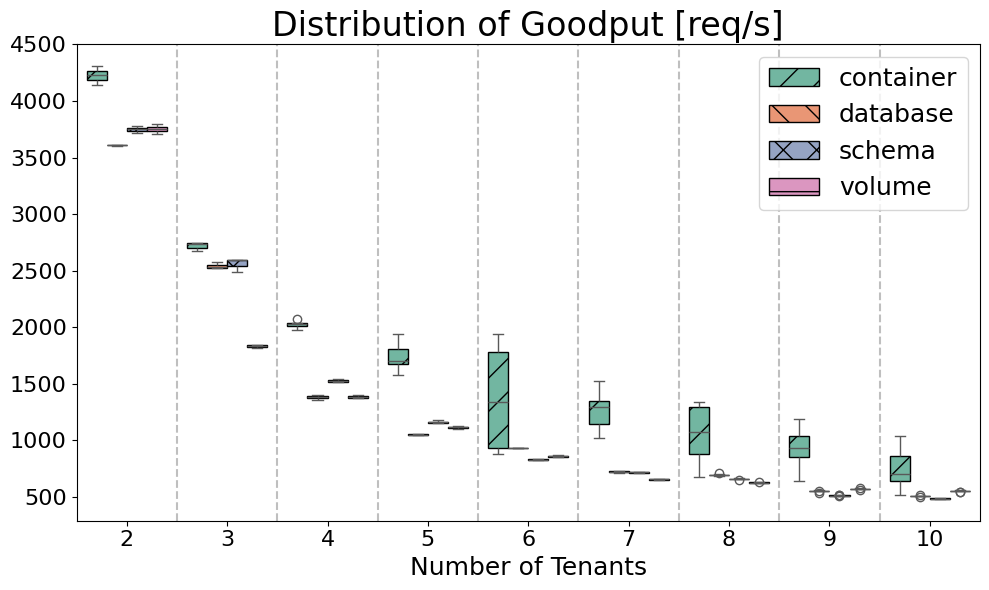

In [42]:
plot_boxplots(df_performance_first, y='Goodput (requests/second)', title='Distribution of Goodput [req/s]')

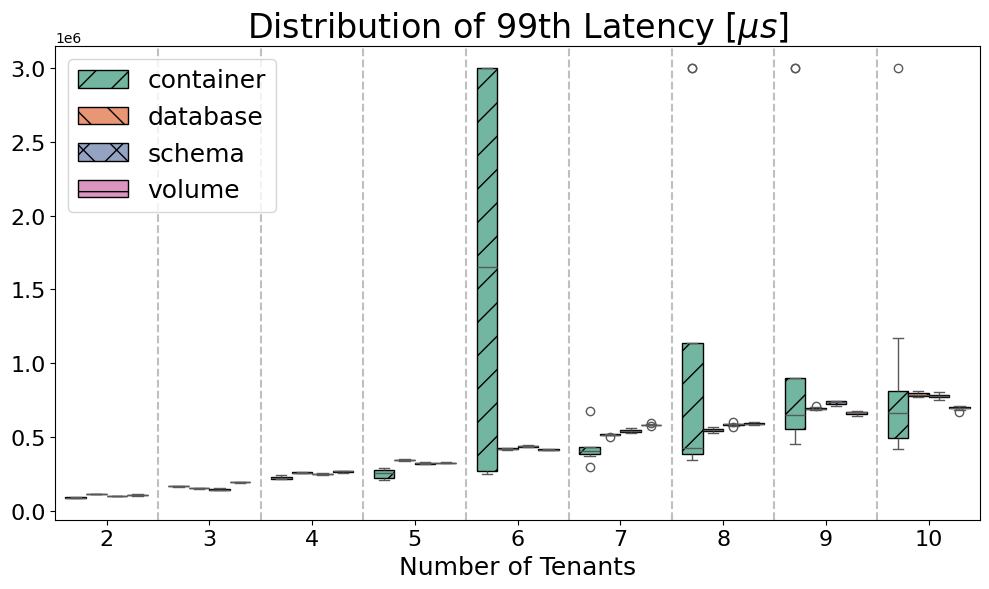

In [43]:
plot_boxplots(df_performance_first, y='Latency Distribution.99th Percentile Latency (microseconds)', title='Distribution of 99th Latency [$\mu s$]')

# Performance Results per Total

In [44]:
df_performance = collect.get_performance_all()
df_performance.loc[df_performance['vol_tenants'] == True, 'type'] = 'volume'

df_performance_first = df_performance[df_performance['client']=='1']
df_performance_second = df_performance[df_performance['client']=='2']

df_performance.dropna(inplace=True)
df_performance

,client,Goodput (requests/second),num_errors,Latency Distribution.Average Latency (microseconds),Latency Distribution.99th Percentile Latency (microseconds),type,num_tenants,vol_tenants,code
0,1,8453.029774,234,23244.000000,95454,container,2,False,1764606625
1,2,7821.582975,183,25116.500000,108101,container,2,False,1764606625
0,1,7217.524506,186,27180.500000,117192,database,2,False,1764603141
1,2,4812.887998,73,40973.500000,123992,database,2,False,1764603141
0,1,7496.977985,172,26183.000000,104982,schema,2,False,1764601398
1,2,4580.594934,61,43061.500000,124227,schema,2,False,1764601398
0,1,7505.266478,163,26158.000000,114418,volume,2,True,1764604857
1,2,4768.554589,64,41382.000000,115745,volume,2,True,1764604857
0,1,8154.267820,224,36103.000000,171795,container,3,False,1764613774
1,2,7630.766499,172,38594.666667,167554,container,3,False,1764613774


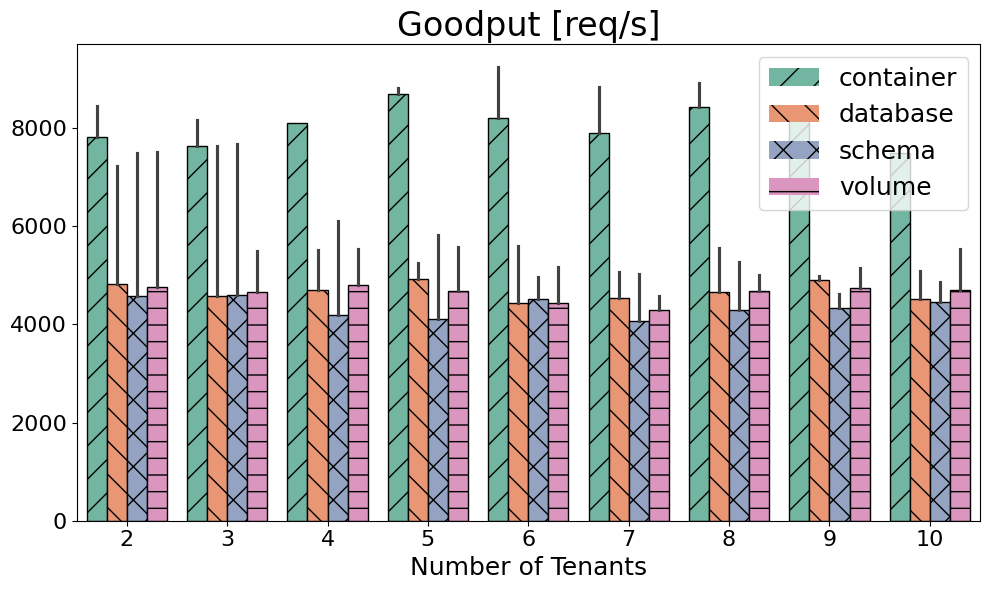

In [45]:
plot_bars(df_performance, y='Goodput (requests/second)', title='Goodput [req/s]', estimator='min')

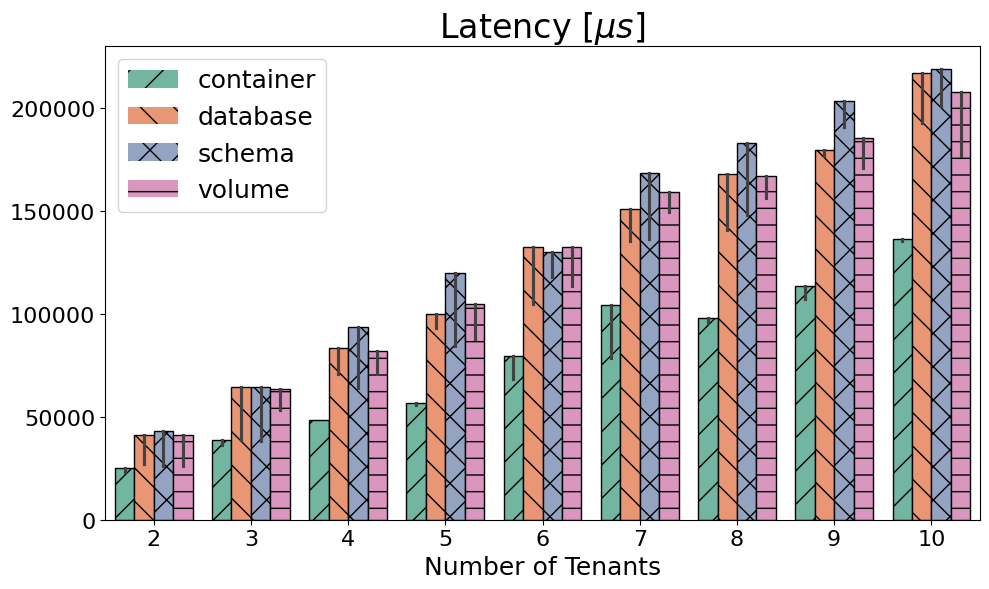

In [46]:
plot_bars(df_performance, y='Latency Distribution.Average Latency (microseconds)', title='Latency [$\mu s$]', estimator='max')

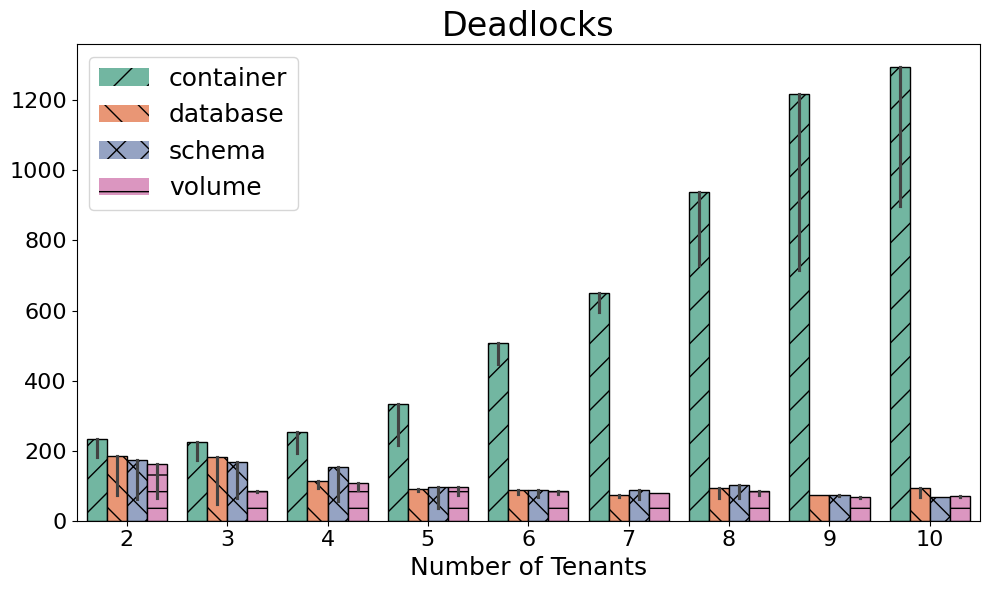

In [47]:
plot_bars(df_performance, y='num_errors', title='Deadlocks', estimator='max')

In [48]:
df_performance = collect.get_loading_time_max_all()
df_performance.loc[df_performance['vol_tenants'] == True, 'type'] = 'volume'

df_performance_first = df_performance[df_performance['client']=='1']
df_performance_second = df_performance[df_performance['client']=='2']

df_performance

,time_load,time_ingest,time_check,terminals,pods,tenant,client,datadisk,type,num_tenants,vol_tenants,code
PostgreSQL-1-1-65536-0-1,264.0,116.0,148.0,1,1,0,1,2719,container,2,False,1764606625
PostgreSQL-1-1-65536-0-2,264.0,116.0,148.0,1,1,0,2,10373,container,2,False,1764606625
PostgreSQL-1-1-65536-1-1,269.0,122.0,147.0,1,1,1,1,2719,container,2,False,1764606625
PostgreSQL-1-1-65536-1-2,269.0,122.0,147.0,1,1,1,2,10658,container,2,False,1764606625
PostgreSQL-1-1-65536-1,317.0,133.0,182.0,1,2,,1,5414,database,2,False,1764603141
PostgreSQL-1-1-65536-2,317.0,133.0,182.0,1,2,,2,18495,database,2,False,1764603141
PostgreSQL-1-1-65536-1,314.0,131.0,181.0,1,2,,1,5399,schema,2,False,1764601398
PostgreSQL-1-1-65536-2,314.0,131.0,181.0,1,2,,2,19070,schema,2,False,1764601398
PostgreSQL-1-1-65536-1,314.0,127.0,185.0,1,2,,1,5414,volume,2,True,1764604857
PostgreSQL-1-1-65536-2,314.0,127.0,185.0,1,2,,2,19157,volume,2,True,1764604857


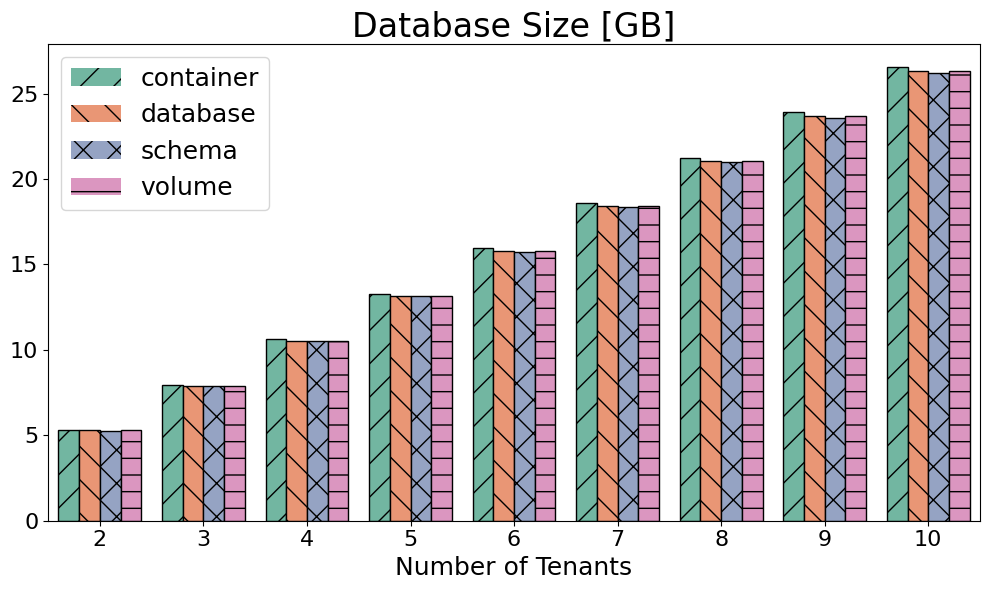

In [49]:
df_performance_first = df_performance[df_performance['client'] == '1']
# Divide datadisk by the count of rows with the same type and num_tenants
df = df_performance_first.copy()
# Create a mask for rows where type is not "container"
mask = df['type'] != 'container'

# Only apply the group count to the relevant rows
group_counts = df[mask].groupby(['type', 'num_tenants'])['datadisk'].transform('count')

# Initialize the column with NaN (or 0, if preferred)
df['datadisk_normalized'] = df['datadisk'] / 1024

# Apply the normalized value only where the mask is True
df.loc[mask, 'datadisk_normalized'] = df.loc[mask, 'datadisk'] / group_counts / 1024

plot_bars(df, y='datadisk_normalized', title='Database Size [GB]', estimator='sum')

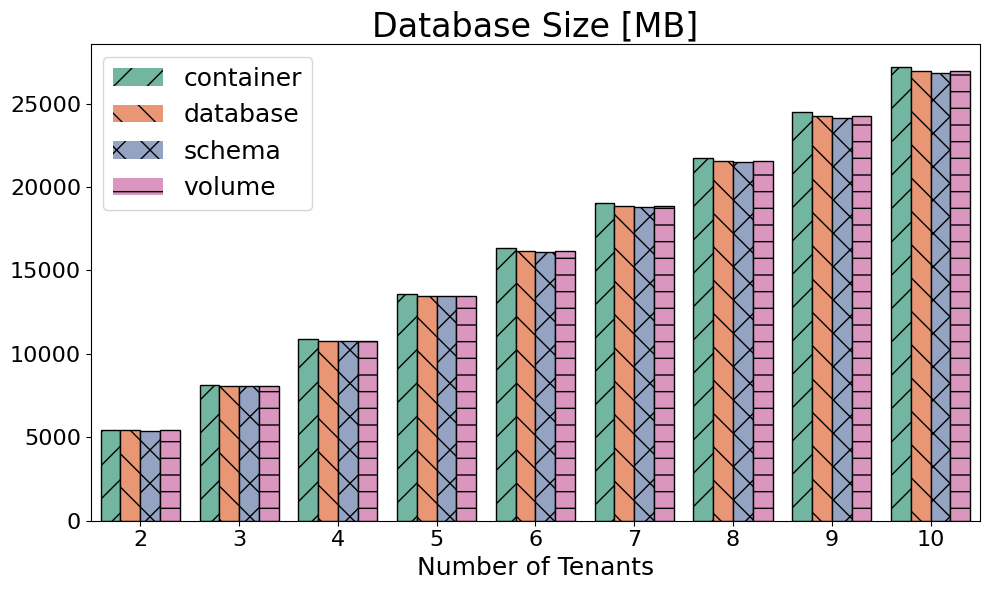

In [50]:
plot_bars(df_performance_first, y='datadisk', title='Database Size [MB]', estimator='sum')

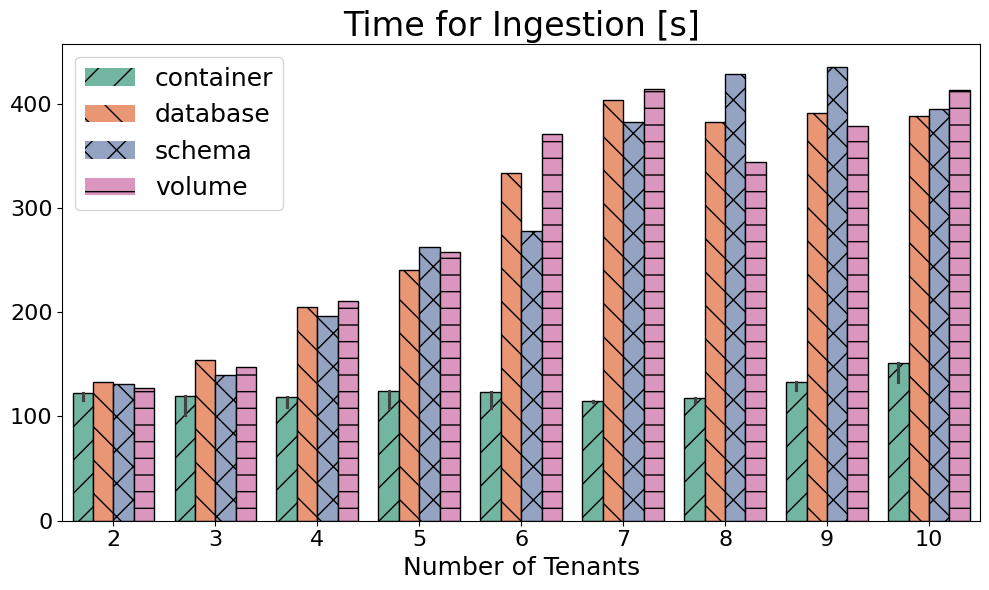

In [51]:
plot_bars(df_performance_first, y='time_ingest', title='Time for Ingestion [s]', estimator='max')

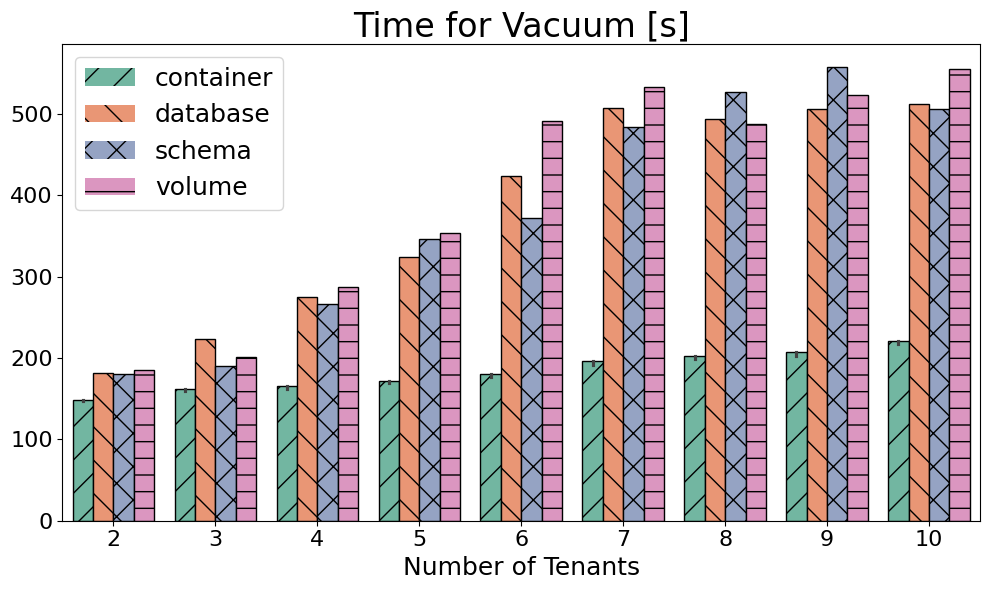

In [52]:
plot_bars(df_performance_first, y='time_check', title='Time for Vacuum [s]', estimator='max')

# Hardware Monitoring for Benchmarking Phase

In [60]:
df_performance = collect.get_monitoring_all(type="stream")
df_performance.loc[df_performance['vol_tenants'] == True, 'type'] = 'volume'

df_performance_first = df_performance[df_performance['client']=='1']
df_performance_second = df_performance[df_performance['client']=='2']

df_performance.T

,0,1,0,1,0,1,0,1,0,1,...,0,1,0,1,0,1,0,1,0,1
client,1,2,1,2,1,2,1,2,1,2,...,1,2,1,2,1,2,1,2,1,2
Memory Usage [MiB],19145.25,23864.02,12870.89,16766.28,12968.84,16630.47,13023.33,16840.9,27271.21,31794.56,...,30170.16,33289.39,81863.49,84230.02,33541.09,35633.52,33042.21,35591.5,33590.87,36025.31
Memory Usage Cached [MiB],23319.58,32188.2,16742.4,23913.38,16922.02,23789.53,16993.79,24125.01,32420.43,40890.17,...,40949.27,46611.49,96245.04,107064.05,45451.66,49955.33,44796.14,49770.29,45538.05,50596.31
CPU Utilization,29.71,31.24,26.57,22.64,28.99,21.14,29.04,22.51,36.25,36.43,...,29.19,27.72,39.62,39.99,30.52,28.33,28.64,28.35,31.1,27.05
CPU Throttle,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPU Throttled Time [s],0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
CPU Utilization Time [s],18132.71,19704.23,16325.72,13419.23,18160.02,13832.97,18850.61,14289.64,24332.35,22811.36,...,19296.63,17225.85,25456.19,24805.56,20394.47,17759.26,17501.04,17978.74,20365.07,16953.73
CPU User Time [s],11533.54,11910.99,10065.23,7607.46,10977.9,7764.72,11414.14,8140.4,14898.32,14534.02,...,11828.73,10569.25,16146.84,15584.64,12731.46,11042.61,10945.54,11109.79,12741.03,10361.53
CPU System Time [s],6599.17,7793.24,6260.49,5811.77,7182.12,6068.24,7436.46,6149.24,9434.04,8277.34,...,7467.9,6656.59,9309.38,9220.91,7663.01,6716.65,6555.5,6868.94,7624.04,6592.21
Network Rx Total [MiB],34288.5,24370.37,29718.52,16909.57,31187.18,17136.33,30950.35,16158.36,33630.69,27521.72,...,21274.27,13996.31,30215.11,30887.68,20961.17,12642.85,20589.2,12387.41,23238.68,14570.2


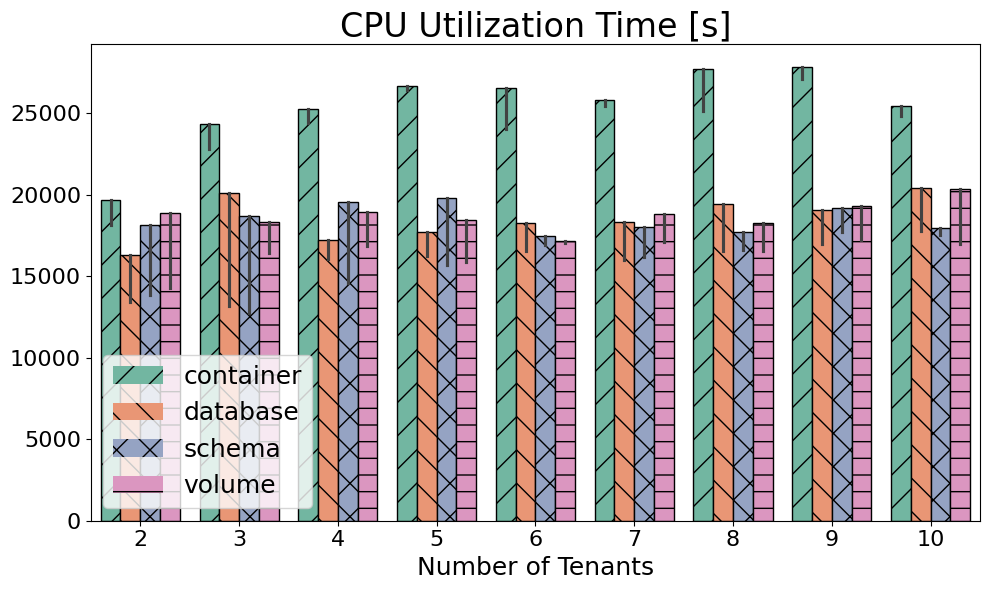

In [62]:
plot_bars(df_performance, y='CPU Utilization Time [s]', title='CPU Utilization Time [s]', estimator='max')

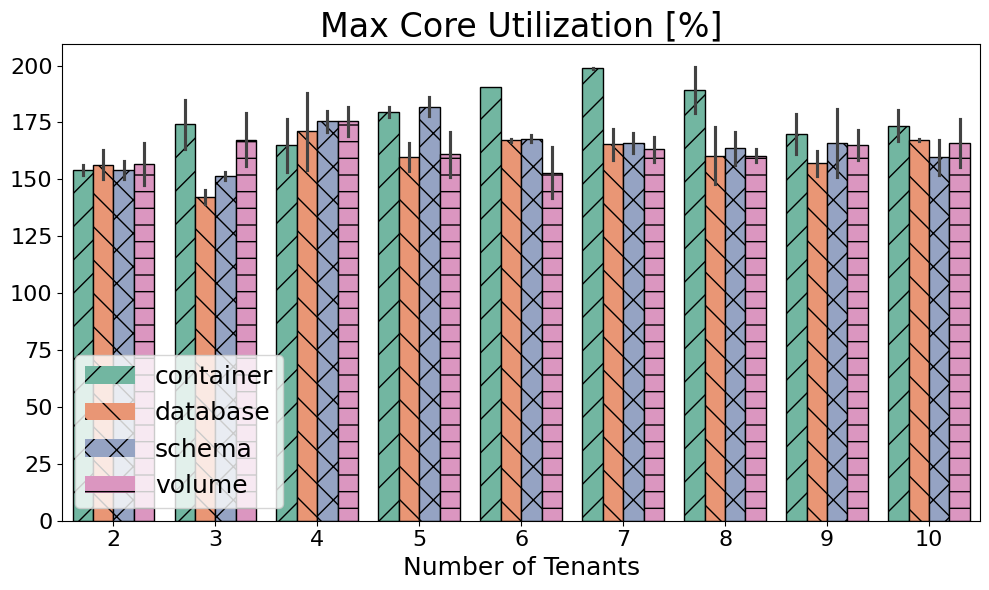

In [63]:
plot_bars(df_performance, y='Max Core Utilization [%]', title='Max Core Utilization [%]', estimator='sum')

In [ ]:
plot_bars(df_performance, y='CPU Throttled', title='CPU Throttled', estimator='sum')

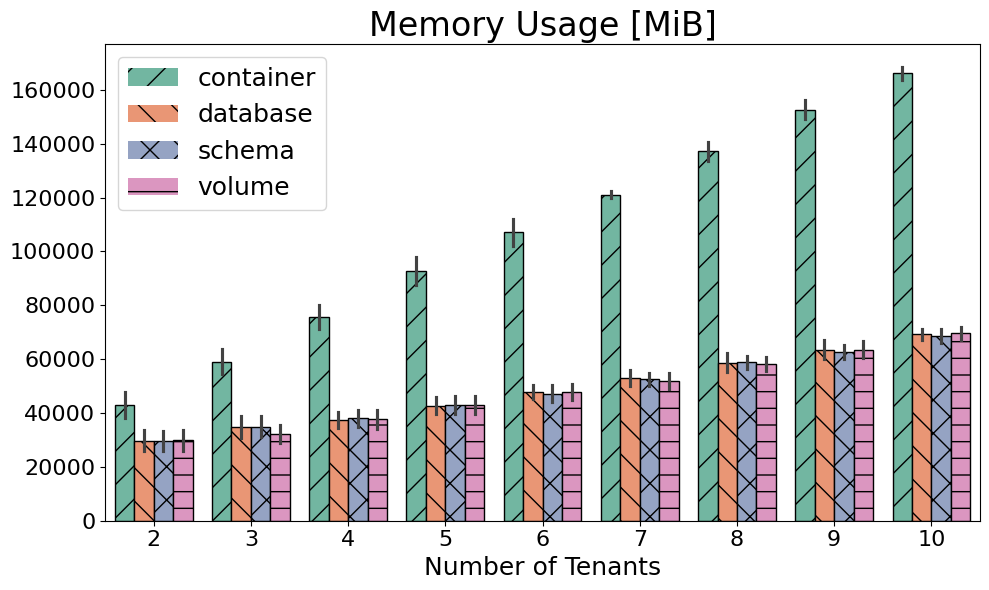

In [64]:
plot_bars(df_performance, y='Memory Usage [MiB]', title='Memory Usage [MiB]', estimator='sum')

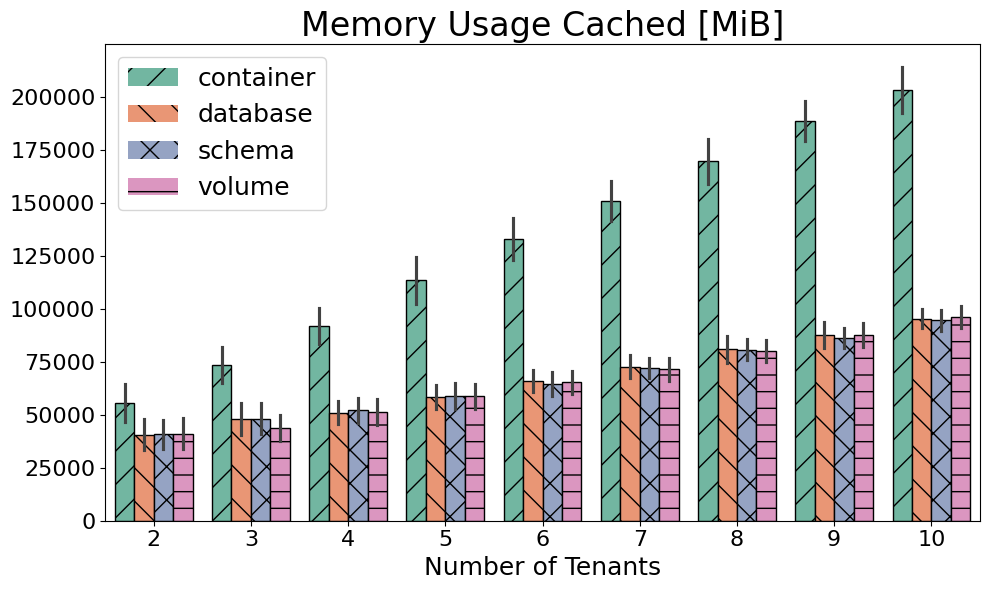

In [65]:
plot_bars(df_performance, y='Memory Usage Cached [MiB]', title='Memory Usage Cached [MiB]', estimator='sum')

# Hardware Monitoring for Loading Phase

In [66]:
df_performance = collect.get_monitoring_all("loading")
df_performance.loc[df_performance['vol_tenants'] == True, 'type'] = 'volume'

df_performance_first = df_performance[df_performance['client']=='1']
df_performance_second = df_performance[df_performance['client']=='2']

df_performance

,client,Memory Usage [MiB],Memory Usage Cached [MiB],CPU Utilization,CPU Throttle,CPU Throttled Time [s],CPU Utilization Time [s],CPU User Time [s],CPU System Time [s],Network Rx Total [MiB],...,Filesystem Read Total [MiB],Filesystem Write Total [MiB],Core Utilization Variance [%],Max Core Utilization [%],I/O Wait [%],Total I/O Wait Time [s],type,num_tenants,vol_tenants,code
0,1,13938.89,14773.76,3.23,0.0,0.0,575.76,523.32,52.44,2079.18,...,0.01,0.00,0.77,12.85,3.73,136.36,container,2,False,1764606625
1,2,13938.89,14773.76,3.23,0.0,0.0,575.76,523.32,52.44,2079.18,...,0.01,0.00,0.77,12.85,3.73,136.36,container,2,False,1764606625
0,1,7638.76,8627.79,3.86,0.0,0.0,852.83,769.69,83.14,2258.53,...,0.00,0.01,0.71,12.54,1.80,93.92,database,2,False,1764603141
1,2,7638.76,8627.79,3.86,0.0,0.0,852.83,769.69,83.14,2258.53,...,0.00,0.01,0.71,12.54,1.80,93.92,database,2,False,1764603141
0,1,7645.24,8641.46,4.07,0.0,0.0,849.92,763.00,86.92,2253.16,...,0.03,0.02,0.84,25.14,2.92,98.60,schema,2,False,1764601398
1,2,7645.24,8641.46,4.07,0.0,0.0,849.92,763.00,86.92,2253.16,...,0.03,0.02,0.84,25.14,2.92,98.60,schema,2,False,1764601398
0,1,7644.47,8648.12,3.47,0.0,0.0,825.56,743.85,81.71,2260.71,...,0.00,0.01,0.73,14.04,2.69,88.45,volume,2,True,1764604857
1,2,7644.47,8648.12,3.47,0.0,0.0,825.56,743.85,81.71,2260.71,...,0.00,0.01,0.73,14.04,2.69,88.45,volume,2,True,1764604857
0,1,21228.11,22883.21,8.19,0.0,0.0,1451.00,1324.98,126.01,3329.87,...,0.01,0.00,1.06,24.76,3.62,206.43,container,3,False,1764613774
1,2,21228.11,22883.21,8.19,0.0,0.0,1451.00,1324.98,126.01,3329.87,...,0.01,0.00,1.06,24.76,3.62,206.43,container,3,False,1764613774


In [67]:
plot_bars(df_performance, y='CPU [CPUs]', title='CPU [CPUs]', estimator='max')

ValueError: Could not interpret value `CPU [CPUs]` for `y`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

In [ ]:
plot_bars(df_performance, y='Max CPU', title='Max CPU', estimator='sum')

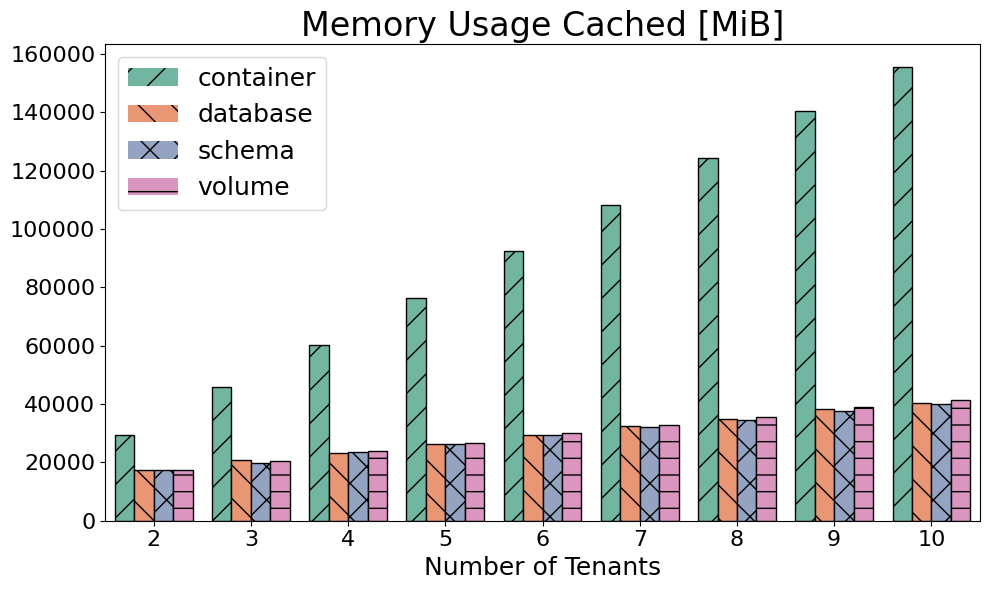

In [68]:
plot_bars(df_performance, y='Memory Usage Cached [MiB]', title='Memory Usage Cached [MiB]', estimator='sum')

# Efficiency

In [74]:
client = '1'

df_performance_monitoring = collect.get_monitoring_all(type="stream")
df_performance_monitoring = df_performance_monitoring[df_performance_monitoring['client'] == client]
df_performance_monitoring.loc[df_performance_monitoring['vol_tenants'] == True, 'type'] = 'volume'
df_performance = collect.get_performance_all()
df_performance = df_performance[df_performance['client'] == client]
df_performance.loc[df_performance['vol_tenants'] == True, 'type'] = 'volume'
merged_df = pd.merge(df_performance, df_performance_monitoring, on=['type', 'num_tenants', 'code', 'client'], how='inner')
#merged_df['I_Lat'] = 1./merged_df['E_Lat']
merged_df['E_Tpx'] = merged_df['Goodput (requests/second)'] / merged_df['CPU Utilization Time [s]'] * 600.
merged_df['E_Lat'] = 1./np.sqrt(merged_df['Latency Distribution.Average Latency (microseconds)']*merged_df['CPU Utilization Time [s]']/1E6)
merged_df['E_RAM'] = (merged_df['Goodput (requests/second)']) / merged_df['Memory Usage [MiB]']
merged_df

,client,Goodput (requests/second),num_errors,Latency Distribution.Average Latency (microseconds),Latency Distribution.99th Percentile Latency (microseconds),type,num_tenants,vol_tenants_x,code,Memory Usage [MiB],...,Filesystem Read Total [MiB],Filesystem Write Total [MiB],Core Utilization Variance [%],Max Core Utilization [%],I/O Wait [%],Total I/O Wait Time [s],vol_tenants_y,E_Tpx,E_Lat,E_RAM
0,1,8453.029774,234,23244.000000,95454,container,2,False,1764606625,19145.25,...,0.00,0.00,1.48,76.04,1.71,225.95,False,279.705453,0.048709,0.441521
1,1,7217.524506,186,27180.500000,117192,database,2,False,1764603141,12870.89,...,0.00,0.00,1.63,74.99,1.23,201.29,False,265.257196,0.047472,0.560763
2,1,7496.977985,172,26183.000000,104982,schema,2,False,1764601398,12968.84,...,0.00,0.00,1.68,75.02,1.52,197.38,False,247.697238,0.045860,0.578076
3,1,7505.266478,163,26158.000000,114418,volume,2,True,1764604857,13023.33,...,0.02,0.01,1.63,73.83,1.52,203.85,True,238.886693,0.045033,0.576294
4,1,8154.267820,224,36103.000000,171795,container,3,False,1764613774,27271.21,...,0.00,0.00,0.66,92.49,1.06,161.14,False,201.072264,0.033739,0.299006
5,1,7623.798159,183,38593.000000,155263,database,3,False,1764610137,15346.94,...,0.00,0.00,1.35,72.72,1.38,203.91,False,227.203045,0.035875,0.496763
6,1,7670.928171,168,38378.333333,156496,schema,3,False,1764608414,15472.40,...,0.01,0.00,1.43,74.86,1.30,172.48,False,246.349333,0.037345,0.495781
7,1,5496.904619,85,53465.333333,196344,volume,3,True,1764611918,14474.20,...,0.01,0.00,0.96,77.94,0.82,130.70,True,179.711503,0.031924,0.379773
8,1,8104.012946,193,48429.750000,243047,container,4,False,1764621210,35559.21,...,0.00,0.00,0.20,76.70,1.10,119.11,False,199.252222,0.029088,0.227902
9,1,5524.086332,114,70894.000000,267694,database,4,False,1764617502,17233.92,...,0.00,0.00,1.57,77.17,1.06,196.31,False,192.374432,0.028613,0.320536


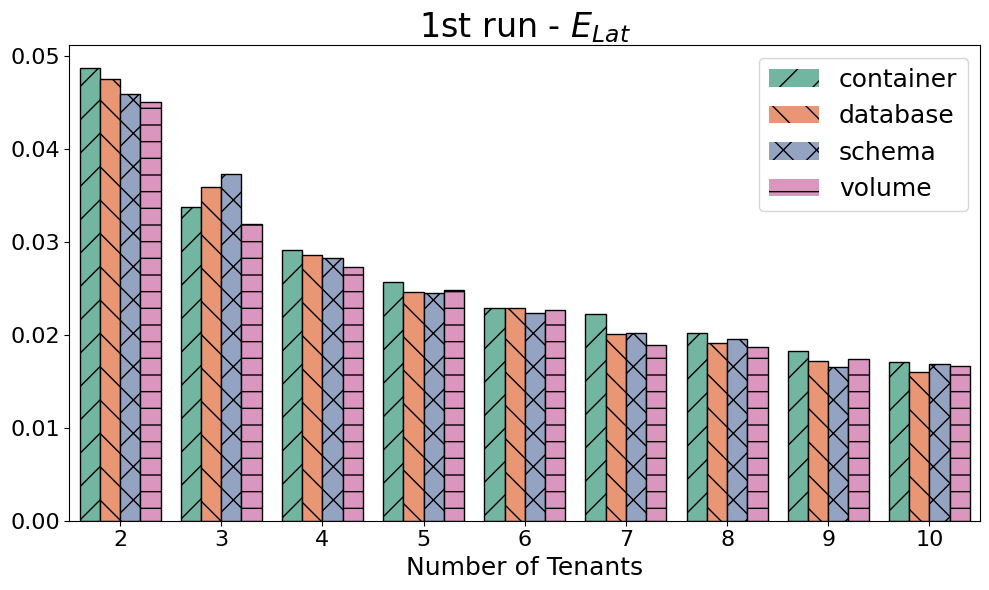

In [75]:
plot_bars(merged_df, y='E_Lat', title='1st run - $E_{Lat}$', estimator='max')

In [76]:
#plot_bars(merged_df, y='I_Lat', title='1st run - $I_{Lat}$', estimator='max')

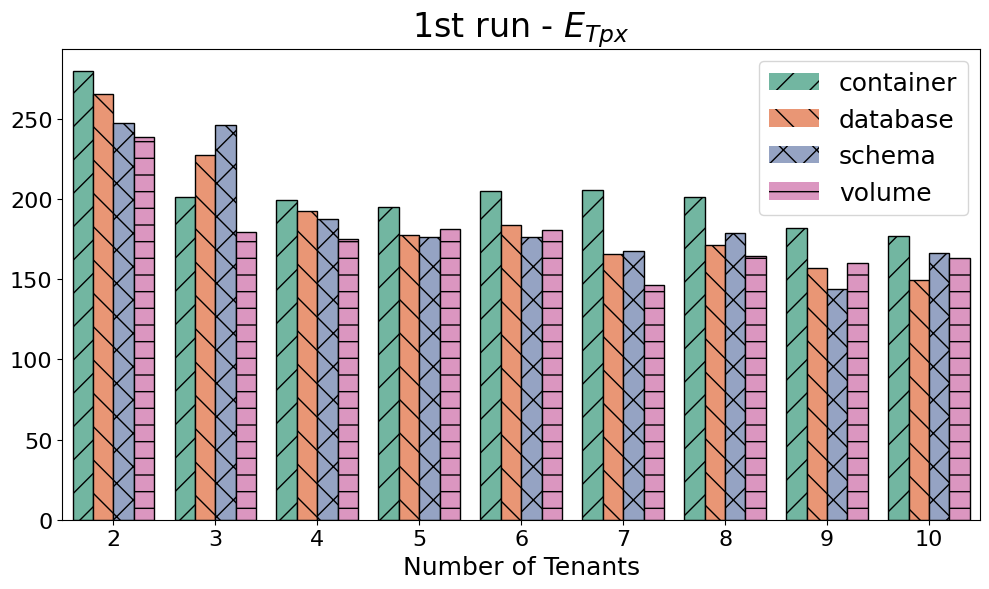

In [77]:
plot_bars(merged_df, y='E_Tpx', title='1st run - $E_{Tpx}$', estimator='max')

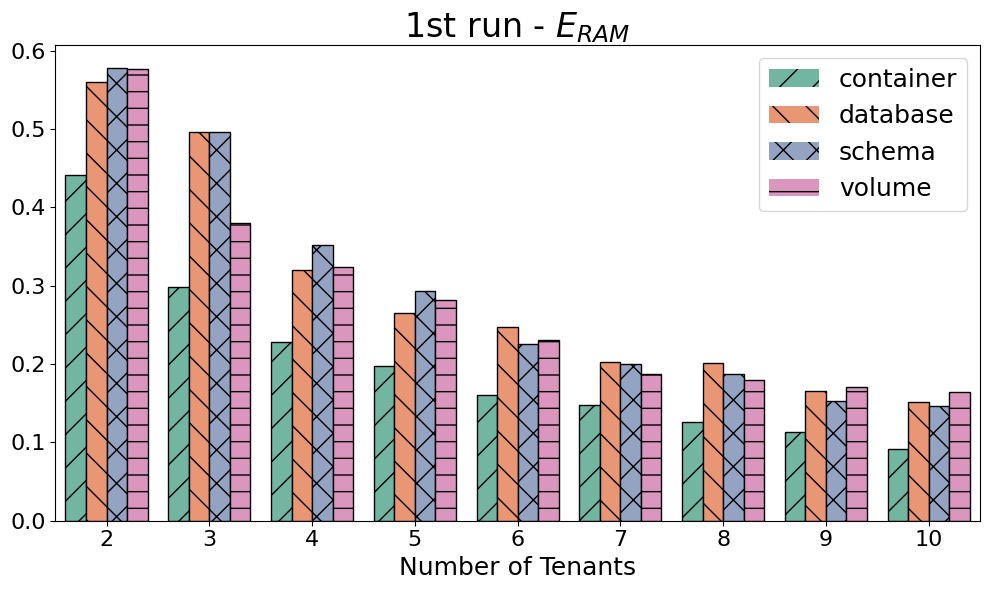

In [78]:
plot_bars(merged_df, y='E_RAM', title='1st run - $E_{RAM}$', estimator='min')

In [ ]:
client = '2'

df_performance_monitoring = collect.get_monitoring_all(type="stream")
df_performance_monitoring = df_performance_monitoring[df_performance_monitoring['client'] == client]
df_performance = collect.get_performance_all()
df_performance = df_performance[df_performance['client'] == client]
merged_df = pd.merge(df_performance, df_performance_monitoring, on=['type', 'num_tenants', 'code', 'client'], how='inner')
#merged_df['CPUs/Request'] = merged_df['CPU [CPUs]'] / merged_df['Goodput (requests/second)'] / 600.
merged_df['E_Tpx'] = merged_df['Goodput (requests/second)'] / merged_df['CPU [CPUs]'] * 600.
merged_df['E_Lat'] = 1./np.sqrt(merged_df['Latency Distribution.Average Latency (microseconds)']*merged_df['CPU [CPUs]']/1E6)
merged_df['E_RAM'] = (merged_df['Goodput (requests/second)']) / merged_df['Max RAM [Gb]']

merged_df

In [ ]:
plot_bars(merged_df, y='E_Lat', title='2nd run - $E_{Lat}$', estimator='max')

In [ ]:
plot_bars(merged_df, y='E_Tpx', title='2nd run - $E_{Tpx}$', estimator='max')

In [ ]:
plot_bars(merged_df, y='E_RAM', title='2nd run - $E_{RAM}$', estimator='max')

In [ ]:
import os
import zipfile

def zip_all_results():
    # Set the base directory containing the folders
    base_dir = path # "/path/to/your/folders"  # CHANGE THIS to your actual directory
    # List all folder names in the directory
    folder_names = codes
    # Create a zip for each folder
    for folder in folder_names:
        folder_path = os.path.join(base_dir, folder)
        zip_path = os.path.join(base_dir, f"{folder}.zip")
        print(f"Zipping {folder_path} to {zip_path}...")
        with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
            for root, _, files in os.walk(folder_path):
                for file in files:
                    abs_path = os.path.join(root, file)
                    rel_path = os.path.relpath(abs_path, folder_path)
                    zipf.write(abs_path, arcname=os.path.join(folder, rel_path))
    print("✅ Done zipping all folders.")


In [ ]:
#zip_all_results()